# 8장 실습 — 합성곱 SNN(CSNN) 학습

**Spiking Neural Networks 쿡북 with Python** · 8장 실습 노트북

합성곱 층과 스파이킹 뉴런을 결합한 **CSNN**으로 MNIST를 분류한다. 학습 방법(대리 경사 + BPTT)은 7장과 같고, `nn.Conv2d`로 공간 특징을 뽑는 점만 다르다.

### 학습 목표
- `nn.Sequential`로 Conv–Pool–LIF 블록을 쌓아 CSNN을 만든다.
- `utils.reset`과 시간 전개 순전파 함수를 사용한다.
- `SF.ce_rate_loss`로 레이트 기반 손실을 정의하고 학습한다.
- 정확도 곡선과 테스트 정확도를 확인한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF   # 스파이크 손실·정확도
from snntorch import utils              # 상태 초기화
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(42)
device = torch.device('cpu')
batch_size = 128

## 2. 데이터 준비 (MNIST)

7장과 동일하게 일부만 사용해 빠르게 학습한다.

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose(
    [transforms.ToTensor(), 
     transforms.Normalize((0,), (1,))]
)
mnist_train = datasets.MNIST(
    '/tmp/data/mnist', 
    train=True, 
    download=True, 
    transform=transform
)
mnist_test = datasets.MNIST(
    '/tmp/data/mnist', 
    train=False, 
    download=True, 
    transform=transform
)

mnist_train = utils.data_subset(mnist_train, subset=20)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)
print('학습 샘플 수:', len(mnist_train))

학습 샘플 수: 3000


## 3. CSNN 정의 — Conv–Pool–LIF 블록

`nn.Sequential`로 합성곱·풀링·스파이킹 뉴런을 쌓는다. `init_hidden=True`는 막전위를 층 내부에서 관리하고, 마지막 층의 `output=True`는 (스파이크, 막전위)를 함께 반환하게 한다. 모든 `snn.Leaky`에 대리 경사를 지정한다.

In [3]:
spike_grad = surrogate.fast_sigmoid(slope=25)   # 대리 경사
beta = 0.5
num_steps = 25

net = nn.Sequential(
    nn.Conv2d(1, 12, 5),                                                  # 합성곱 1
    nn.MaxPool2d(2),                                                      # 풀링 1
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),        # 스파이킹 1
    nn.Conv2d(12, 64, 5),                                                 # 합성곱 2
    nn.MaxPool2d(2),                                                      # 풀링 2
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),        # 스파이킹 2
    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 10),                                           # 완전연결 → 10클래스
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True),  # 출력 스파이킹
).to(device)

print(net)

Sequential(
  (0): Conv2d(1, 12, kernel_size=(5, 5), stride=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Leaky()
  (3): Conv2d(12, 64, kernel_size=(5, 5), stride=(1, 1))
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Leaky()
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1024, out_features=10, bias=True)
  (8): Leaky()
)


## 4. 시간 전개 순전파 함수

같은 이미지를 `num_steps`번 흘리며 출력 스파이크·막전위를 시간 축으로 쌓는다. 순전파 시작 전 `utils.reset`으로 모든 뉴런의 막전위를 초기화한다.

In [4]:
def forward_pass(net, num_steps, data):
    spk_rec, mem_rec = [], []
    utils.reset(net)                       # 모든 LIF 막전위 초기화
    for step in range(num_steps):
        spk_out, mem_out = net(data)       # 한 시간 스텝 순전파
        spk_rec.append(spk_out)
        mem_rec.append(mem_out)
    return torch.stack(spk_rec), torch.stack(mem_rec)

## 5. 손실·옵티마이저와 학습 루프

손실은 `SF.ce_rate_loss` — 출력 뉴런의 **발화율**에 교차 엔트로피를 적용한다. `backward()`가 BPTT를 수행한다. 매 반복마다 손실과 정확도(`SF.accuracy_rate`)를 출력한다.

In [5]:
loss_fn = SF.ce_rate_loss()
optimizer = torch.optim.Adam(net.parameters(), lr=2e-3, betas=(0.9, 0.999))

loss_hist, acc_hist = [], []
net.train()
for data, targets in train_loader:
    data = data.to(device)
    targets = targets.to(device)

    spk_rec, _ = forward_pass(net, num_steps, data)   # 시간 전개 순전파
    loss_val = loss_fn(spk_rec, targets)              # 레이트 기반 손실

    optimizer.zero_grad()
    loss_val.backward()       # BPTT
    optimizer.step()

    acc = SF.accuracy_rate(spk_rec, targets)          # 누적 스파이크 정확도
    loss_hist.append(loss_val.item())
    acc_hist.append(acc)
    print(f'손실 {loss_val.item():.3f} | 배치 정확도 {acc*100:.1f}%')

손실 2.303 | 배치 정확도 10.2%
손실 2.303 | 배치 정확도 12.5%
손실 2.303 | 배치 정확도 6.2%
손실 2.303 | 배치 정확도 7.8%
손실 2.303 | 배치 정확도 10.9%
손실 2.303 | 배치 정확도 10.9%
손실 2.303 | 배치 정확도 7.8%
손실 2.303 | 배치 정확도 6.2%
손실 2.303 | 배치 정확도 9.4%
손실 2.303 | 배치 정확도 11.7%
손실 2.303 | 배치 정확도 10.9%
손실 2.303 | 배치 정확도 7.8%
손실 2.303 | 배치 정확도 6.2%
손실 2.303 | 배치 정확도 8.6%
손실 2.303 | 배치 정확도 10.2%
손실 2.303 | 배치 정확도 6.2%
손실 2.303 | 배치 정확도 11.7%
손실 2.303 | 배치 정확도 16.4%
손실 2.303 | 배치 정확도 7.8%
손실 2.299 | 배치 정확도 9.4%
손실 2.290 | 배치 정확도 14.8%
손실 2.266 | 배치 정확도 25.8%
손실 2.251 | 배치 정확도 25.0%


## 6. 학습 곡선

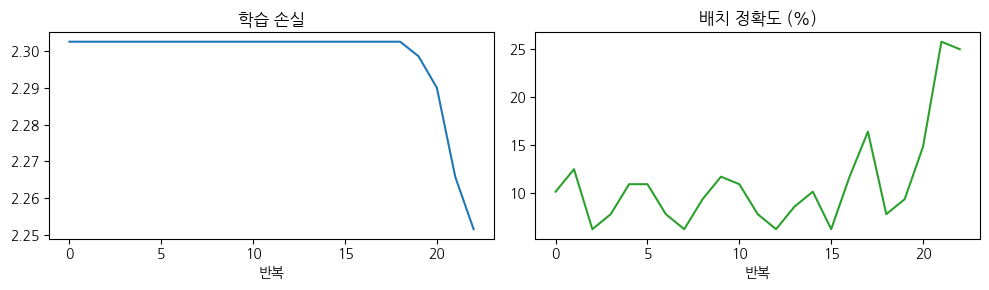

In [6]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3))
a0.plot(loss_hist, color='tab:blue'); a0.set_title('학습 손실'); a0.set_xlabel('반복')
a1.plot([a*100 for a in acc_hist], color='tab:green'); a1.set_title('배치 정확도 (%)'); a1.set_xlabel('반복')
plt.tight_layout(); plt.show()

## 7. 테스트 정확도 평가

테스트셋 전체에 대해 발화율 기반 정확도를 계산한다.

In [7]:
def measure_accuracy(net, data_loader, num_steps):
    total = 0
    acc = 0.0
    net.eval()
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device)
            targets = targets.to(device)
            spk_rec, _ = forward_pass(net, num_steps, data)
            acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
            total += spk_rec.size(1)
    return acc / total

test_acc = measure_accuracy(net, test_loader, num_steps)
print(f'테스트 정확도: {test_acc*100:.2f}%')

테스트 정확도: 31.07%


## 정리

- CSNN은 Conv–Pool–LIF 블록을 쌓아 만들며, 학습은 7장과 동일하게 대리 경사 + BPTT다.
- `utils.reset`으로 매 순전파마다 막전위를 초기화한다.
- `SF.ce_rate_loss`는 출력 발화율에 교차 엔트로피를 적용한 손실이다.
- 합성곱이 공간 특징을 잡아 완전연결 SNN보다 효율적으로 높은 정확도에 도달한다.

이로써 3부를 마친다. 4부에서는 뉴로모픽 데이터셋·회귀·오토인코더 같은 실전 레시피로 나아간다.